# Daniel's Guide to Quantifying Uncertainty in the Structure Function and Derived Statistics

This uncertainty arises from 
1. Measurement uncertainty
2. Sampling uncertainty
3. Fitting uncertainty

## Next steps
- Tidy code
- Add equations from Overleaf
- Work on real data application

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
# Add .. to the path
import sys

sys.path.append("..")
import src.sf_funcs as sf_funcs

## Bootstrap re-sampling (simulation study)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Generate a synthetic time series: fractional Gaussian noise (fGn)
# We'll simulate an approximate fGn using an AR(1) process for simplicity
np.random.seed(42)
n = 1000
phi = 0.9  # autocorrelation coefficient
noise = np.random.normal(0, 1, n)
ts_sim = np.zeros(n)
for i in range(1, n):
    ts_sim[i] = phi * ts_sim[i - 1] + noise[i]

# Block bootstrap implementation
def block_bootstrap_sf(x, max_lag, block_size, n_bootstraps=1000):
    n = len(x)
    n_blocks = n // block_size
    sf_boot = np.zeros((n_bootstraps, max_lag))
    x_boot_all = []

    for b in range(n_bootstraps):
        indices = np.random.randint(0, n_blocks, n_blocks)
        x_boot = np.concatenate(
            [x[i * block_size : (i + 1) * block_size] for i in indices]
        )
        x_boot_all.append(x_boot)
        sf_boot[b] = sf_funcs.compute_sf(
            pd.DataFrame(x_boot), np.arange(1, max_lag + 1), [2], False, False, None
        ).sf_2

    return sf_boot, x_boot_all


# Parameters
max_lag = 50
block_size = 100
n_bootstraps = 100

# Compute original SF and bootstrapped confidence intervals
# For Voyager data
ts = ts_sim

sf_orig = sf_funcs.compute_sf(
    pd.DataFrame(ts), np.arange(1, max_lag+1), [2], False, False, None
)
sf_boot, x_boot = block_bootstrap_sf(ts, max_lag, block_size, n_bootstraps)

Text(0.5, 1.0, 'Another Bootstrapped Time Series')

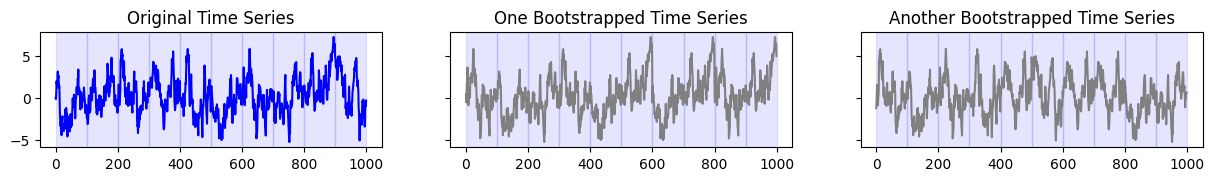

In [3]:
fig, ax = plt.subplots(1,3, figsize=(15, 1.5), sharey=True)
ax[0].plot(ts_sim, label="Simulated Time Series", color="blue")
# Highlight the blocks
for i in range(len(x_boot[0]) // block_size):
    start = i * block_size
    end = start + block_size
    ax[0].axvspan(start, end, color="blue", alpha=0.1)
    ax[1].axvspan(start, end, color="blue", alpha=0.1)
    ax[2].axvspan(start, end, color="blue", alpha=0.1)
ax[1].plot(x_boot[0],c="grey")
ax[2].plot(x_boot[-1], c="grey")
ax[0].set_title("Original Time Series")
ax[1].set_title("One Bootstrapped Time Series")
ax[2].set_title("Another Bootstrapped Time Series")

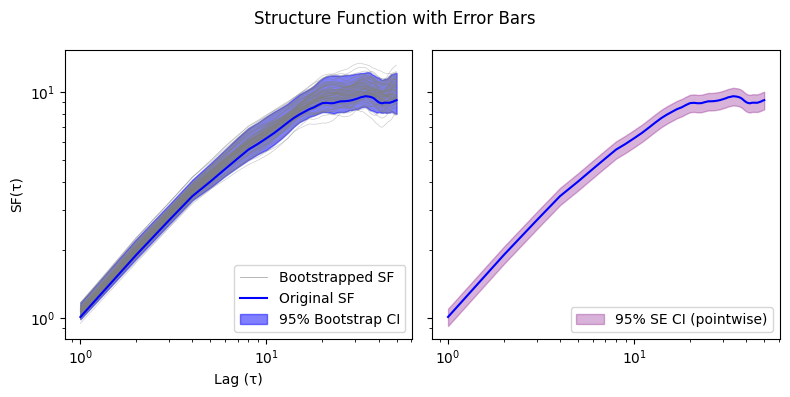

In [10]:
ci_lower = np.percentile(sf_boot, 2.5, axis=0)
ci_upper = np.percentile(sf_boot, 97.5, axis=0)

# Plot
lags = np.arange(1, max_lag + 1)

# Calculate standard error assuming chi-squared approximation (pointwise error bars)
n_pairs = np.array([len(ts) - tau for tau in range(1, max_lag + 1)])
sf_se = sf_orig.sf_2 * np.sqrt(2 / (n_pairs - 1))
ci_se_lower = sf_orig.sf_2 - 1.96 * sf_se
ci_se_upper = sf_orig.sf_2 + 1.96 * sf_se

# Plot with both bootstrap and pointwise SE intervals using fig, ax syntax
fig, ax = plt.subplots(1,2, figsize=(8, 4), sharey=True)
for sf in sf_boot:
    ax[0].plot(lags, sf, color="grey", alpha=0.4, lw=0.5)
ax[0].plot(lags[0], sf_boot[0][0], color="grey", alpha=0.8, lw = 0.5, label="Bootstrapped SF")
ax[0].plot(lags, sf_orig.sf_2, label="Original SF", color="blue")
ax[1].plot(lags, sf_orig.sf_2, color="blue")
ax[0].fill_between(
    lags, ci_lower, ci_upper, color="blue", alpha=0.5, label="95% Bootstrap CI"
)
ax[1].fill_between(
    lags,
    ci_se_lower,
    ci_se_upper,
    color="purple",
    alpha=0.3,
    label="95% SE CI (pointwise)"
)
plt.suptitle("Structure Function with Error Bars")
ax[0].set_xlabel("Lag (τ)")
ax[0].set_ylabel("SF(τ)")
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[0].legend(loc="lower right")
ax[1].legend(loc="lower right")
fig.tight_layout()
plt.show()

We can see that the bootstrap interval is generally wider, especially at larger lags, reflecting the additional uncertainty due to autocorrelation and non-Gaussianity.

## Artificially add noise

In [ ]:
# Block bootstrap implementation
def noise_bootstrap_sf(x, max_lag, sigma, n_bootstraps=1000):
    n = len(x)
    sf_boot = np.zeros((n_bootstraps, max_lag))
    x_boot_all = []

    for b in range(n_bootstraps):
        x_boot = x + np.random.normal(0, sigma, len(x))
        x_boot_all.append(x_boot)
        sf_boot[b] = sf_funcs.compute_sf(
            pd.DataFrame(x_boot), np.arange(1, max_lag + 1), [2], False, False, None
        ).sf_2

    return sf_boot, x_boot_all

# Compute original SF and bootstrapped confidence intervals
# For Voyager data
ts = ts_sim
sigma = 1.0  # Standard deviation of noise

sf_orig = sf_funcs.compute_sf(
    pd.DataFrame(ts), np.arange(1, max_lag + 1), [2], False, False, None
)
sf_boot, x_boot = noise_bootstrap_sf(ts, max_lag, sigma, n_bootstraps)

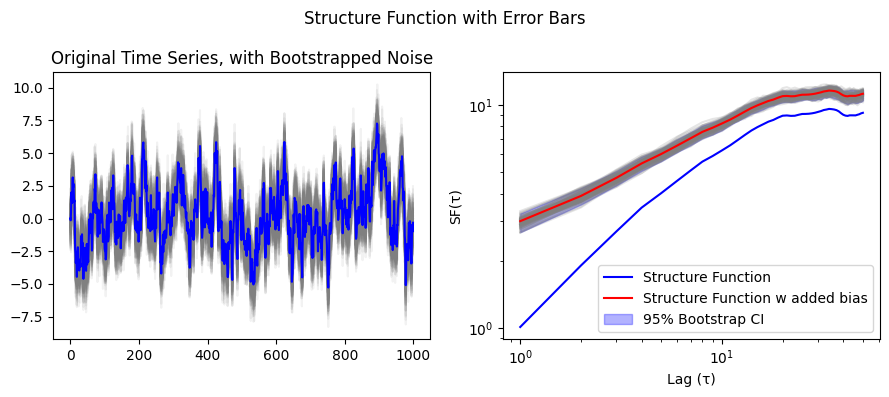

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(9, 4))
for i, x in enumerate(x_boot):
    ax[0].plot(x, c="grey", alpha=0.1)
ax[0].plot(ts_sim, label="Simulated Time Series", color="blue")
ax[0].set_title("Original Time Series, with Bootstrapped Noise")

ci_lower = np.percentile(sf_boot, 2.5, axis=0)
ci_upper = np.percentile(sf_boot, 97.5, axis=0)

# Plot
lags = np.arange(1, max_lag + 1)

# Calculate standard error assuming chi-squared approximation (pointwise error bars)
n_pairs = np.array([len(ts) - tau for tau in range(1, max_lag + 1)])
sf_se = sf_orig.sf_2 * np.sqrt(2 / (n_pairs - 1))
ci_se_lower = sf_orig.sf_2 - 1.96 * sf_se
ci_se_upper = sf_orig.sf_2 + 1.96 * sf_se

# Plot with both bootstrap and pointwise SE intervals using fig, ax[1] syntax[1]
for sf in sf_boot:
    ax[1].plot(lags, sf, color="grey", alpha=0.2)
ax[1].plot(lags, sf_orig.sf_2, label="Structure Function", color="blue")
ax[1].plot(
    lags, sf_orig.sf_2 + 2 * sigma, label="Structure Function w added bias", color="red"
)
ax[1].fill_between(
    lags, ci_lower, ci_upper, color="blue", alpha=0.3, label="95% Bootstrap CI"
)
ax[1].set_xlabel("Lag (τ)")
ax[1].set_ylabel("SF(τ)")
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].legend()
fig.tight_layout()
plt.show()

## Real data application

- As a demonstration dataset, we'll be working with the some magnetic field data from the Local Interstellar Medium, as measured by Voyager 2. The radial component of this data has particularly large measurement errors.
- NB: Low signal-to-noise ratio for Voyager is making corrected-SF negative. **Try just adding Gaussian noise with given sigma to time series, and run a bootstrap-like model with this. Compare this to corrected values.**

In [ ]:
data_full = pd.read_pickle("../data/interim/voyager/voyager1_lism_cleaned.pkl")
data_res = data_full.resample("1D").mean()
data_res.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4146 entries, 2012-08-25 to 2023-12-31
Freq: D
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   F1      3969 non-null   float32
 1   BR      3969 non-null   float32
 2   BT      3969 non-null   float32
 3   BN      3969 non-null   float32
dtypes: float32(4)
memory usage: 97.2 KB


Text(0, 0.5, '$B_T$ (nT)')

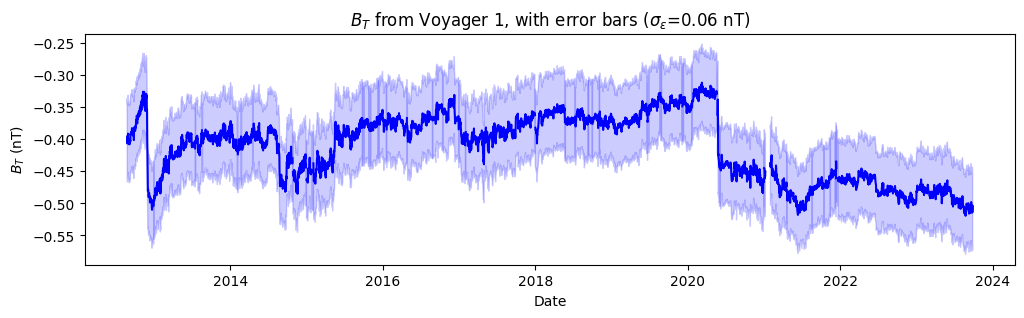

In [ ]:
# Plot error bars as shaded region
br_error = 0.06
# Source: Rankin et al. (2023) 

plt.figure(figsize=(12, 3))
plt.plot(data_res.index, data_res["BT"], label="BT", color="blue")
plt.fill_between(
    data_res.index,
    data_res["BT"] - br_error,
    data_res["BT"] + br_error,
    color="blue",
    alpha=0.2,
)
plt.title("$B_T$ from Voyager 1, with error bars ($\sigma_{\epsilon}$=0.06 nT)")
plt.xlabel("Date")
plt.ylabel("$B_T$ (nT)")